In [5]:
%pip install stable-baselines3 gymnasium mujoco

     -------------------------------------- 187.5/187.5 KB 2.8 MB/s eta 0:00:00
     ---------------------------------------- 5.8/5.8 MB 12.0 MB/s eta 0:00:00
     -------------------------------------- 122.9/122.9 MB 7.7 MB/s eta 0:00:00
     ------------------------------------- 952.1/952.1 KB 12.1 MB/s eta 0:00:00
     ------------------------------------- 170.6/170.6 KB 10.0 MB/s eta 0:00:00
     ---------------------------------------- 135.8/135.8 KB ? eta 0:00:00
     ------------------------------------- 559.5/559.5 KB 11.7 MB/s eta 0:00:00
     ---------------------------------------- 3.2/3.2 MB 13.6 MB/s eta 0:00:00
     ---------------------------------------- 1.7/1.7 MB 11.0 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 KB 3.9 MB/s eta 0:00:00
     ---------------------------------------- 6.3/6.3 MB 16.1 MB/s eta 0:00:00
     ------------------------------------- 203.4/203.4 KB 12.9 MB/s eta 0:00:00
     -------------------------------------- 536.2

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\edward\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [6]:
%pip install matplotlib numpy pandas scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\edward\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [7]:
import gymnasium as gym
from gymnasium import spaces
import mujoco
import numpy as np
import os

class SegwayEnv(gym.Env):
    def __init__(self, xml_path="segway_ed.xml"):
        super().__init__()

        self.model = mujoco.MjModel.from_xml_path(xml_path)
        self.data = mujoco.MjData(self.model)
        self.dt = self.model.opt.timestep

        self.max_force = 100.0

        self.observation_space = spaces.Box(
            low=np.array([-10, -np.pi, -20, -20], dtype=np.float32),
            high=np.array([10, np.pi, 20, 20], dtype=np.float32),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=np.array([-self.max_force], dtype=np.float32),
            high=np.array([self.max_force], dtype=np.float32),
            dtype=np.float32,
        )

    def get_obs(self):
        return np.array([
            self.data.qpos[0],
            self.data.qpos[1],
            self.data.qvel[0],
            self.data.qvel[1],
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.data = mujoco.MjData(self.model)

        self.data.qpos[0] = 0.0
        self.data.qpos[1] = self.np_random.uniform(-0.15, 0.15)
        self.data.qvel[0] = self.np_random.uniform(-0.5, 0.5)
        self.data.qvel[1] = self.np_random.uniform(-0.5, 0.5)

        mujoco.mj_forward(self.model, self.data)

        return self.get_obs(), {}

    def step(self, action):
        u = float(np.clip(action[0], -self.max_force, self.max_force))
        self.data.ctrl[0] = u

        mujoco.mj_step(self.model, self.data)

        obs = self.get_obs()

        x = obs[0]
        theta = obs[1]
        x_dot = obs[2]
        theta_dot = obs[3]

        reward = (
            10.0
            - 50.0 * theta**2
            - 2.0 * theta_dot**2
            - 0.5 * x**2
            - 0.01 * u**2
        )

        terminated = abs(theta) > 0.7 or abs(x) > 4.5
        truncated = False

        return obs, reward, terminated, truncated, {}

In [8]:
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor

env = SegwayEnv("segway_ed.xml")
env = Monitor(env)

model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    buffer_size=100000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
)

model.learn(total_timesteps=10000)

model.save("sac_segway")

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 440      |
|    ep_rew_mean     | -444     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 40       |
|    time_elapsed    | 42       |
|    total_timesteps | 1758     |
| train/             |          |
|    actor_loss      | 6.24     |
|    critic_loss     | 3.99     |
|    ent_coef        | 1.08     |
|    ent_coef_loss   | -0.00669 |
|    learning_rate   | 0.0003   |
|    n_updates       | 1657     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 413      |
|    ep_rew_mean     | 18.2     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 37       |
|    time_elapsed    | 88       |
|    total_timesteps | 3301     |
| train/             |          |
|    actor_loss      | 5.67   

In [9]:
env = SegwayEnv("segway_ed.xml")

obs, _ = env.reset()

states = []
controls = []

for k in range(3000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    states.append(obs)
    controls.append(action[0])

    if terminated or truncated:
        break

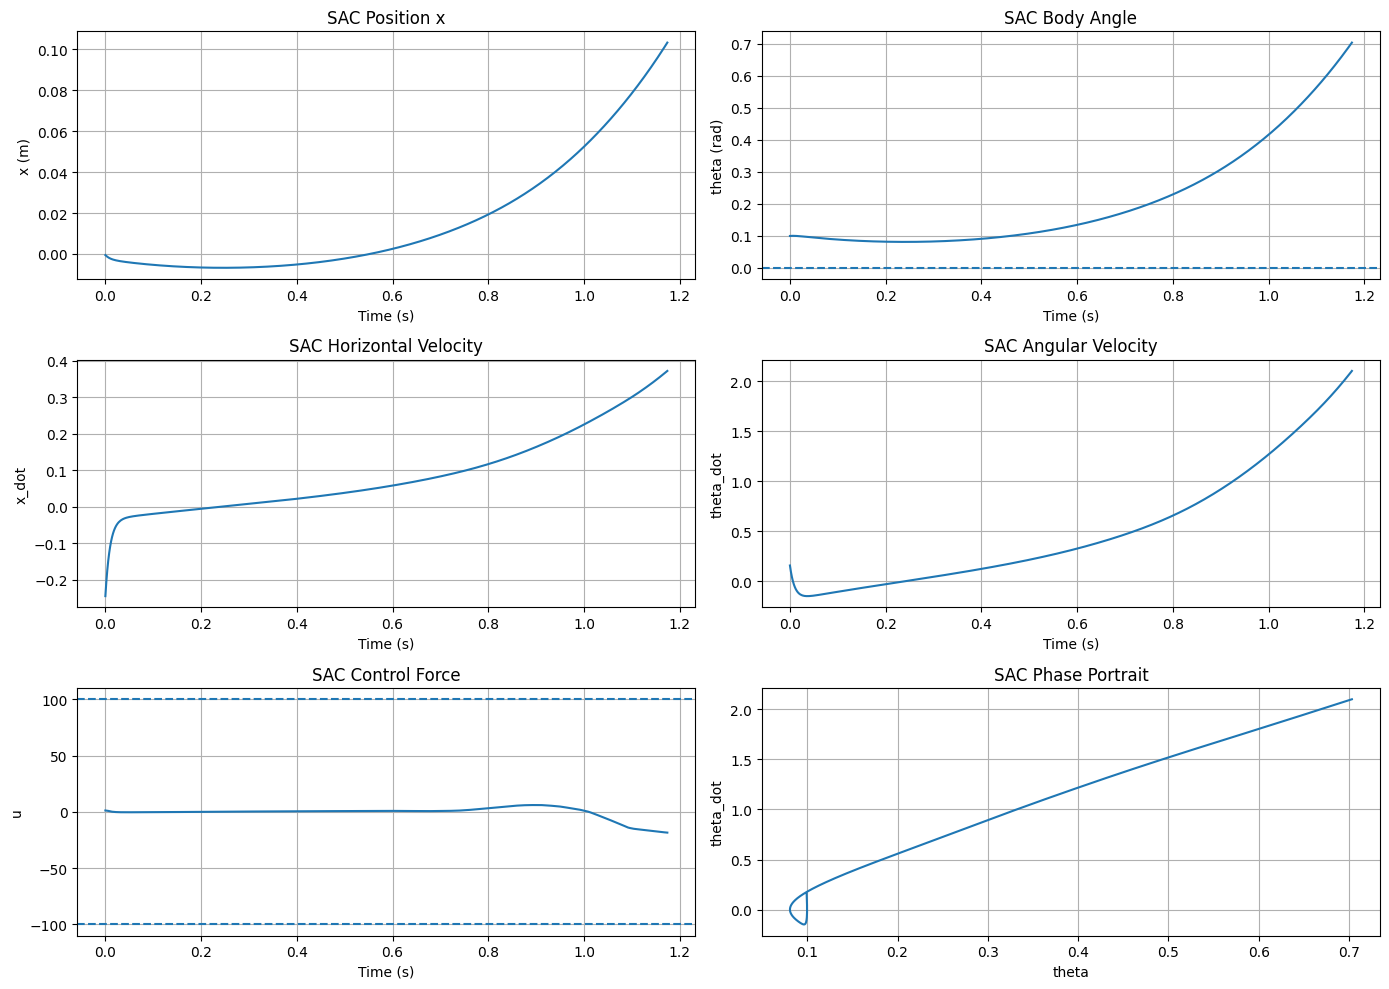

In [10]:
import matplotlib.pyplot as plt
import numpy as np

states = np.array(states)
controls = np.array(controls)
time = np.arange(len(states)) * env.dt

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

axes[0, 0].plot(time, states[:, 0])
axes[0, 0].set_title("SAC Position x")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("x (m)")
axes[0, 0].grid(True)

axes[0, 1].plot(time, states[:, 1])
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("SAC Body Angle")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("theta (rad)")
axes[0, 1].grid(True)

axes[1, 0].plot(time, states[:, 2])
axes[1, 0].set_title("SAC Horizontal Velocity")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("x_dot")
axes[1, 0].grid(True)

axes[1, 1].plot(time, states[:, 3])
axes[1, 1].set_title("SAC Angular Velocity")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("theta_dot")
axes[1, 1].grid(True)

axes[2, 0].plot(time, controls)
axes[2, 0].axhline(100, linestyle="--")
axes[2, 0].axhline(-100, linestyle="--")
axes[2, 0].set_title("SAC Control Force")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("u")
axes[2, 0].grid(True)

axes[2, 1].plot(states[:, 1], states[:, 3])
axes[2, 1].set_title("SAC Phase Portrait")
axes[2, 1].set_xlabel("theta")
axes[2, 1].set_ylabel("theta_dot")
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()